## Imports

In [95]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import pickle

In [4]:
data_sheart = pd.read_csv("data/heart.csv") #https://www.kaggle.com/datasets/yasserh/heart-disease-dataset
data_churn = pd.read_csv("data/employee_churn_dataset.csv") #https://www.kaggle.com/datasets/ziya07/employee-churn-data?
data_heart = pd.read_csv("data/heart_disease_health_indicators_BRFSS2015.csv") #https://www.kaggle.com/datasets/alexteboul/heart-disease-health-indicators-dataset
data_fraud = pd.read_csv("data/transactions_sept_oct_2023.csv") #data science challenge

## Preliminary 

### Data treatment

In [5]:
# Modify data_churn 

data_churn = data_churn[data_churn["Gender"]!='Other']
data_churn.drop("Employee ID", inplace=True, axis=1)

gender_map = {"Male": 0, "Female": 1}
education_map = {"High School": 0, "Bachelor's": 1, "Master's": 2, "PhD": 3}
marital_map = {"Single": 0, "Married": 1, "Divorced": 2}
jobrole_map = {"Analyst": 0, "Manager": 1, "Sales": 2, "Developer": 3}
department_map = {"HR": 0, "IT": 1, "Sales": 2, "Marketing": 3}
workmode_map = {"Remote": 0, "On-site": 1, "Hybrid": 2}
performance_map = {"Poor": 0, "Average": 1, "Good": 2, "Excellent": 3}

data_churn["Gender"] = data_churn["Gender"].map(gender_map)
data_churn["Education Level"] = data_churn["Education Level"].map(education_map)
data_churn["Marital Status"] = data_churn["Marital Status"].map(marital_map)
data_churn["Job Role"] = data_churn["Job Role"].map(jobrole_map)
data_churn["Department"] = data_churn["Department"].map(department_map)
data_churn["Work Location"] = data_churn["Work Location"].map(workmode_map)
data_churn["Work-Life Balance"] = data_churn["Work-Life Balance"].map(performance_map)

# Modify data_heart
df_pos = data_heart[data_heart.HeartDiseaseorAttack == 1].sample(n=500, random_state=0)
df_neg = data_heart[data_heart.HeartDiseaseorAttack == 0].sample(n=9500, random_state=0)
data_heart = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=0)

In [6]:
def data_overview(data, target):

    print("Length of dataset: ", len(data))
    y = data[target]
    print("Positive class proportion (%): ", np.round(y.mean()*100, 1))
    X = data.drop(target, axis=1) 

    return np.array(X), np.array(y)

In [7]:
X_sheart, y_sheart = data_overview(data_sheart, "target")
X_churn, y_churn = data_overview(data_churn, "Churn")
X_heart, y_heart = data_overview(data_heart[:10000], "HeartDiseaseorAttack")
X_fraud, y_fraud = data_overview(data_fraud, "FLAG_FRAUD")

Length of dataset:  303
Positive class proportion (%):  54.5
Length of dataset:  9799
Positive class proportion (%):  20.4
Length of dataset:  10000
Positive class proportion (%):  5.0
Length of dataset:  80000
Positive class proportion (%):  0.1


In [10]:
scaler = MinMaxScaler()
X_sheart = scaler.fit_transform(X_sheart)
X_churn = scaler.fit_transform(X_churn)
X_heart = scaler.fit_transform(X_heart)
X_fraud = scaler.fit_transform(X_fraud)

### Synthetic data generation

In [11]:
def generate_dataset(n_samples=10000, n_features=10, p=0.1, random_state=0):
    """
    Generates a binary classification dataset where y depends on X.
    The positive class has proportion ~p.

    Parameters:
        n_samples (int): number of samples in the dataset 
        n_features (int): number of features in the dataset 
        p (float): proportion of positive samples in the dataset, 0<p<1
        seed (int): generator seed

     Returns:
        np.array: generated design matrix
        np.arry: generated target variable
    """

    # Generate X
    rng = np.random.default_rng(random_state)  
    X = rng.standard_normal((n_samples, n_features))

    #X = np.random.randn(n_samples, n_features, random_state=random_state)

    # Define a true underlying linear model
    #weights = np.random.randn(n_features, random_state=random_state)
    weights = rng.standard_normal(n_features)
    logits = X @ weights

    # Shift threshold to control positive rate
    threshold = np.percentile(logits, 100 * (1 - p))
    y = (logits >= threshold).astype(int)

    return X, y

In [12]:
def cross_val_set(X, y, mode="train_test", test_size=0.2, val_size=None, n_splits=5, random_state=0):
    """
    Create train/test splits using either simple train_test or stratified k-fold.

    Parameters:
        X (np.array): design matrix 
        y (np.array): target variable
        mode (str): 'train_test' or 'kfold'
        test_size (float): used if mode='train_test'
        n_splits (int): used if mode='kfold'
        random_state (int): for reproducibility

    Returns:
        - If mode='train_test' and val_size:
            X_train, X_val, X_test, y_train, y_val, y_test
        - If mode='train_test':
            X_train, X_test, y_train, y_test
        - If mode='kfold':
            List of (X_train, X_test, y_train, y_test)
    """

    if mode == "train_test":
        
        if val_size:
            X_temp, X_test, y_temp, y_test = train_test_split(
                X, y,
                test_size=test_size,
                stratify=y,
                random_state=random_state
            )
            val_relative = val_size / (1 - test_size)
            X_train, X_val, y_train, y_val = train_test_split(
                X_temp, y_temp,
                test_size=val_relative,
                stratify=y_temp,
                random_state=random_state
            )
            return X_train, X_val, X_test, y_train, y_val, y_test

        else:
            X_train, X_test, y_train, y_test = train_test_split(
                X, y,
                test_size=test_size,
                stratify=y,
                shuffle=True,
                random_state=0
            )
            return X_train, X_test, y_train, y_test

    elif mode == "kfold":
        skf = StratifiedKFold(
            n_splits=n_splits, 
            shuffle=True, 
            random_state=0)
        folds = [
            (X[train_idx], X[test_idx], y[train_idx], y[test_idx])
            for train_idx, test_idx in skf.split(X, y)
        ]
        return folds
    
    else:
        raise ValueError("mode should be 'train_test' or 'kfold'")

In [16]:
X_05, y_05 = generate_dataset(p=0.5)
X_train_05, X_test_05, y_train_05, y_test_05 = cross_val_set(X_05, y_05)

X_01, y_01 = generate_dataset()
X_train_01, X_test_01, y_train_01, y_test_01 = cross_val_set(X_01, y_01)

X_005, y_005 = generate_dataset(p=0.05)
X_train_005, X_test_005, y_train_005, y_test_005 = cross_val_set(X_005, y_005)

X_002, y_002 = generate_dataset(p=0.02)
X_train_002, X_test_002, y_train_002, y_test_002 = cross_val_set(X_002, y_002)

X_001, y_001 = generate_dataset(p=0.01)
X_train_001, X_test_001, y_train_001, y_test_001 = cross_val_set(X_001, y_001)

X_train_sheart, X_test_sheart, y_train_sheart, y_test_sheart = cross_val_set(X_sheart, y_sheart)
X_train_churn, X_test_churn, y_train_churn, y_test_churn = cross_val_set(X_churn, y_churn)
X_train_heart, X_test_heart, y_train_heart, y_test_heart = cross_val_set(X_heart, y_heart)
X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = cross_val_set(X_fraud, y_fraud)

### Gradient descent class

In [ ]:
class JointQuantileModel:
    def __init__(self, alpha=0.5, h=0.1, t=0, lr_beta=0.01, lr_tau=0.01, n_iter=100):
        self.alpha = alpha
        self.h = h
        self.t=t
        self.tau = 0.5
        self.theta = np.log(self.tau / (1 - self.tau))
        self.lr_beta = lr_beta
        self.lr_tau = lr_tau
        self.n_iter = n_iter

    def fit(self, X, y, verbose=False):
        n, p = X.shape
        self.beta = np.zeros(p)
        self.loss_history = []

        for it in range(self.n_iter):
            tau = self.tau_from_theta()
            f = X @ self.beta
            Kf = norm.cdf(f / self.h)
            K_prime_f = norm.pdf(f / self.h) / self.h

            # Gradients
            tmp = (1/(1+np.exp((y - Kf)/self.alpha)) - tau)
            grad_beta = (X.T @ (K_prime_f * tmp)) / n
            grad_tau = np.mean(y - Kf)

            # Updates
            self.beta -= self.lr_beta * grad_beta
            self.tau  -= self.lr_tau * grad_tau
            self.tau   = np.clip(self.tau, 1e-3, 1-1e-3)

            # loss
            loss = np.mean(self.tau*(y - Kf) + self.alpha*np.log1p(np.exp(-(y - Kf)/self.alpha)))
            self.loss_history.append(loss)

            if verbose and it % 100 == 0:
                print(f"Iter {it}, Loss={loss:.4f}, tau={self.tau:.4f}")


    # Predict quantile of Y*
    def predict_quantile(self, X):
        f = X @ self.beta
        return f
    
    # Predict Y by thresholding quantile of Y*
    def predict(self, X):
        f = X @ self.beta
        return (f >= self.t).astype(int)
    

    def compute_loss(self, X, y):
        tau = self.tau_from_theta()
        f = X @ self.beta
        Kf = norm.cdf(f/self.h)
        loss = self.tau * (y - Kf) + self.alpha * np.log1p(np.exp(-(y - Kf) / self.alpha))
        return np.mean(loss)

    def tau_from_theta(self):
        return 1 / (1 + np.exp(-self.theta))


    def get_params(self, deep=True):
        return {
            "n_estimators": self.n_estimators,
            "alpha": self.alpha,
            "tau": self.tau,
            "eta": self.eta,
            "h": self.h,
            "t": self.t,
            "base_learner": self.base_learner
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self


    def plot_loss(self):
        plt.figure(figsize=(8, 5))
        plt.plot(self.loss_history, label="Loss")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Training Loss per Iteration")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


In [224]:
class GradSQBC(BaseEstimator):

    def __init__(self, n_estimators=150, alpha=0.5, 
                 tau=0.5, theta=0, eta=0.1, h=0.1, t=0, 
                 random_state=0, base_learner="tree",
                 lr_theta = 0.1):
        if not 0 < tau < 1:
            raise ValueError("tau must be between 0 and 1")
        if base_learner not in ["tree", "OLS"]:
            raise ValueError("base_learner must be 'tree' or 'OLS'")
        self.n_estimators = n_estimators
        self.alpha = alpha
        self.tau = tau
        self.theta = theta
        self.eta = eta
        self.h = h
        self.t = t
        self.random_state = random_state
        self.base_learner = base_learner
        self.lr_theta = lr_theta
    

    def compute_loss(self, X, y):
        f = np.sum([self.eta * m.predict(X) for m in self.models], axis=0)
        Kf = norm.cdf(f/self.h)
        loss = self.tau * (y - Kf) + self.alpha * np.log1p(np.exp(-(y - Kf) / self.alpha))
        return np.mean(loss)


    def fit(self, X, y, verbose=True):
        f = np.zeros(len(y))
        self.models = []
        self.loss_history = []

        for m in range(self.n_estimators):

            Kf = norm.cdf(f/self.h)
            K_prime_f = norm.pdf(f/self.h) / self.h
            U = -K_prime_f * (1/(1 + np.exp((y - Kf)/self.alpha)) - self.tau)
            
            if self.base_learner == "tree":
                model = DecisionTreeRegressor(max_depth=1, random_state=self.random_state)
            elif self.base_learner == "OLS":
                model = LinearRegression()

            model.fit(X, U)
            self.models.append(model)
            f += self.eta * model.predict(X)

            grad_theta = np.mean(y - Kf) * self.tau * (1 - self.tau)
            self.theta -= self.lr_theta * grad_theta
            self.tau = 1 / (1 + np.exp(-self.theta))

            #grad_tau = np.mean(y - Kf)
            #self.tau -= self.lr_tau * grad_tau
            #self.tau = np.clip(self.tau, 1e-3, 1-1e-3)

            # Keep loss
            loss = self.compute_loss(X, y)
            self.loss_history.append(loss)
            if (m % 10 == 0) and verbose:
                print(f"Iter {m}, loss = {loss:.4f}, tau = {self.tau:.4f}")

    
    # Predict quantile of Y*
    def predict_quantile(self, X):
        f = np.sum([self.eta * m.predict(X) for m in self.models], axis=0)
        return f
    

    # Predict Y by thresholding quantile of Y*
    def predict(self, X):
        f = np.sum([self.eta * m.predict(X) for m in self.models], axis=0)
        return (f >= self.t).astype(int)
    
    
    def get_params(self, deep=True):
        return {
            "n_estimators": self.n_estimators,
            "alpha": self.alpha,
            "tau": self.tau,
            "eta": self.eta,
            "h": self.h,
            "t": self.t,
            "base_learner": self.base_learner
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self
    

    def plot_loss(self):
        plt.figure(figsize=(8, 5))
        plt.plot(self.loss_history, label="Loss")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Training Loss per Iteration")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

Iter 0, loss = 0.3921, tau = 0.4997
Iter 10, loss = 0.3707, tau = 0.4996
Iter 20, loss = 0.3683, tau = 0.4998
Iter 30, loss = 0.3671, tau = 0.4999
Iter 40, loss = 0.3661, tau = 0.4999
Iter 50, loss = 0.3653, tau = 0.4997
Iter 60, loss = 0.3647, tau = 0.4994
Iter 70, loss = 0.3641, tau = 0.4990
Iter 80, loss = 0.3636, tau = 0.4985
Iter 90, loss = 0.3631, tau = 0.4979
Iter 100, loss = 0.3627, tau = 0.4972
Iter 110, loss = 0.3623, tau = 0.4964
Iter 120, loss = 0.3618, tau = 0.4956
Iter 130, loss = 0.3615, tau = 0.4946
Iter 140, loss = 0.3612, tau = 0.4936


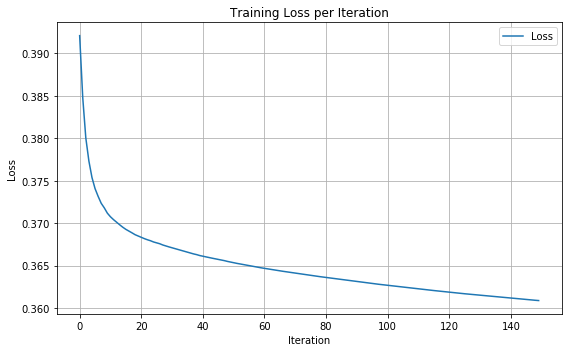

0.4926133928246877


In [225]:
model = GradSQBC()
model.fit(X_train_sheart, y_train_sheart)
model.plot_loss()
print(model.tau)

Iter 0, loss = 0.3869, tau = 0.5018
Iter 10, loss = 0.3840, tau = 0.5021
Iter 20, loss = 0.3839, tau = 0.5006
Iter 30, loss = 0.3838, tau = 0.4990
Iter 40, loss = 0.3837, tau = 0.4971
Iter 50, loss = 0.3836, tau = 0.4950
Iter 60, loss = 0.3835, tau = 0.4926
Iter 70, loss = 0.3833, tau = 0.4898
Iter 80, loss = 0.3831, tau = 0.4867
Iter 90, loss = 0.3829, tau = 0.4832
Iter 100, loss = 0.3826, tau = 0.4792
Iter 110, loss = 0.3822, tau = 0.4747
Iter 120, loss = 0.3818, tau = 0.4696
Iter 130, loss = 0.3812, tau = 0.4639
Iter 140, loss = 0.3805, tau = 0.4575


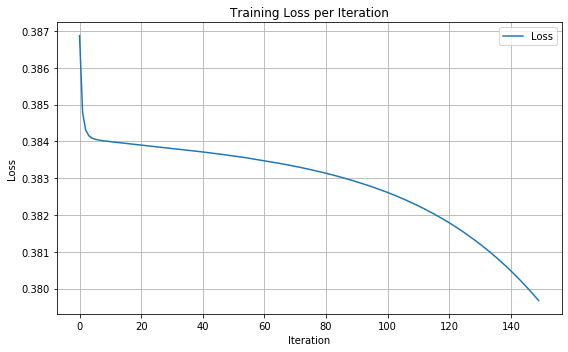

0.45115466244076513


In [226]:
model2 = GradSQBC()
model2.fit(X_train_churn, y_train_churn)
model2.plot_loss()
print(model2.tau)

Iter 0, loss = 0.3628, tau = 0.5028
Iter 10, loss = 0.3566, tau = 0.5068
Iter 20, loss = 0.3563, tau = 0.5083
Iter 30, loss = 0.3561, tau = 0.5097
Iter 40, loss = 0.3560, tau = 0.5110
Iter 50, loss = 0.3559, tau = 0.5123
Iter 60, loss = 0.3559, tau = 0.5138
Iter 70, loss = 0.3558, tau = 0.5153
Iter 80, loss = 0.3557, tau = 0.5170
Iter 90, loss = 0.3557, tau = 0.5187
Iter 100, loss = 0.3556, tau = 0.5206
Iter 110, loss = 0.3555, tau = 0.5227
Iter 120, loss = 0.3554, tau = 0.5250
Iter 130, loss = 0.3553, tau = 0.5275
Iter 140, loss = 0.3551, tau = 0.5302


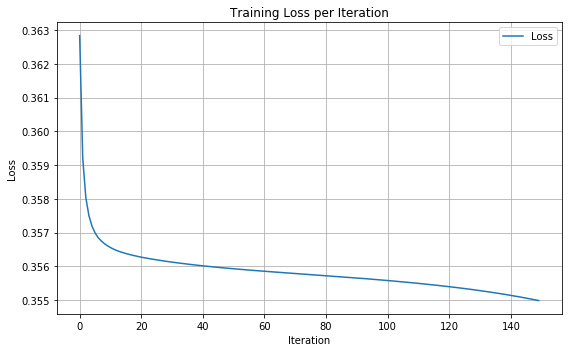

0.532984506418219


In [227]:
model3 = GradSQBC()
model3.fit(X_train_heart, y_train_heart)
model3.plot_loss()
print(model3.tau)

Iter 0, loss = 0.3681, tau = 0.5025
Iter 10, loss = 0.3588, tau = 0.5063
Iter 20, loss = 0.3568, tau = 0.5086
Iter 30, loss = 0.3557, tau = 0.5109
Iter 40, loss = 0.3549, tau = 0.5131
Iter 50, loss = 0.3542, tau = 0.5153
Iter 60, loss = 0.3537, tau = 0.5175
Iter 70, loss = 0.3533, tau = 0.5196
Iter 80, loss = 0.3530, tau = 0.5218
Iter 90, loss = 0.3527, tau = 0.5240
Iter 100, loss = 0.3524, tau = 0.5262
Iter 110, loss = 0.3521, tau = 0.5284
Iter 120, loss = 0.3519, tau = 0.5306
Iter 130, loss = 0.3517, tau = 0.5329
Iter 140, loss = 0.3514, tau = 0.5353


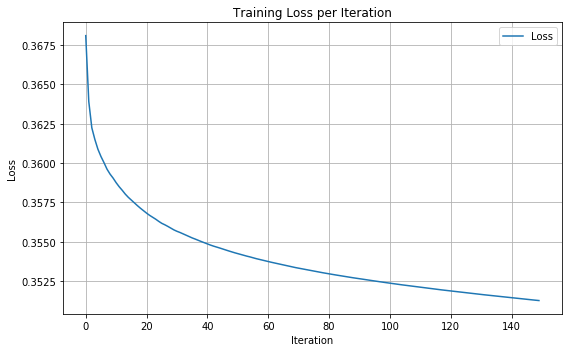

0.5374020908312317


In [228]:
model4 = GradSQBC()
model4.fit(X_train_01, y_train_01)
model4.plot_loss()
print(model4.tau)

### Classification evaluation

In [29]:
# Define personnalized metrics 
 
def specificity_score(y_true, y_pred):
    """
    Computes specificity of classification.

    Parameters: 
        y_true (np.array): true value of target variable
        y_pred (np.array): predicted value of target  variable

    Returns:
    float: specificity score
    """

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    return specificity


def weighted_accuracy_score(y_true, y_pred):
    """
    Computes weighted accuracy according to proportion of positive examples p.

    Parameters: 
        y_true (np.array): true value of target variable
        y_pred (np.array): predicted value of target  variable

    Returuns:
        float: weighted accuracy 
    """
    
    acc_pos = recall_score(y_true, y_pred, zero_division=0) 
    acc_neg = specificity_score(y_true, y_pred)

    p = np.mean(y_true)
    weighted_acc = p * acc_pos + (1 - p) * acc_neg

    return weighted_acc


def cost_score(y_true, y_pred, cost_10=10, cost_01=100, cost_11=10, cost_00=0, normalize=True):
    """
    Computes total cost of classification based on cost matrix.
    Return:
        float: opposite of total coast
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fp*cost_10 + fn*cost_01 + tp*cost_11 + tn*cost_00

    if normalize==True:
        FP = (y_true == 0).sum()
        FN = (y_true == 1).sum()
        max_cost = FP*cost_10 + FN*cost_01 
        total_cost = total_cost / max_cost if max_cost > 0 else 0.0
        
    return -total_cost

In [30]:
def evaluate(y_true, y_pred, cost_10=10, cost_01=100, cost_11=10, cost_00=0, plot=True):
    """
    Returns and plots classification results.

    Parameters: 
        y_true (np.array): true value of target variable
        y_pred (np.array): predicted value of target  variable

    Returns:
        dictionary: evaluation metrics
    """  
    acc = accuracy_score(y_true, y_pred)
    w_acc = balanced_accuracy_score(y_true, y_pred) # harmonic mean of recall and specificty
    rec = recall_score(y_true, y_pred, zero_division=0) 
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    spec = specificity_score(y_true, y_pred)
    cost = -cost_score(y_true, y_pred, 
                        cost_10=cost_10, cost_01=cost_01, 
                        cost_11=cost_11, cost_00=cost_00
                    )

    metrics = {
            "F1-score": round(f1, 3),
            "Accuracy": round(acc, 3),
            "Balanced Accuracy": round(w_acc, 3),
            "Recall": round(rec, 3),
            "Precision": round(prec, 3),
            "Specificity": round(spec, 3),
            "Cost": round(cost, 3)
        }
    
    if plot:
        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
        disp.plot()
        plt.show()

        print(metrics)
    
    return metrics 

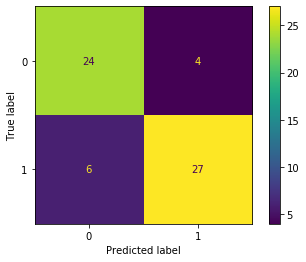

{'F1-score': 0.844, 'Accuracy': 0.836, 'Balanced Accuracy': 0.838, 'Recall': 0.818, 'Precision': 0.871, 'Specificity': 0.857, 'Cost': 0.254}


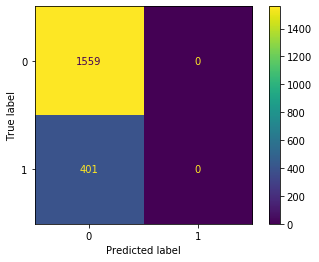

{'F1-score': 0.0, 'Accuracy': 0.795, 'Balanced Accuracy': 0.5, 'Recall': 0.0, 'Precision': 0.0, 'Specificity': 1.0, 'Cost': 0.72}


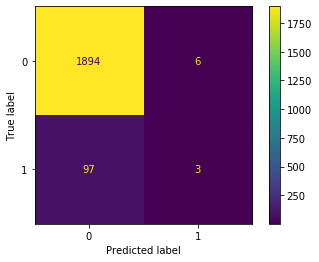

{'F1-score': 0.055, 'Accuracy': 0.948, 'Balanced Accuracy': 0.513, 'Recall': 0.03, 'Precision': 0.333, 'Specificity': 0.997, 'Cost': 0.338}


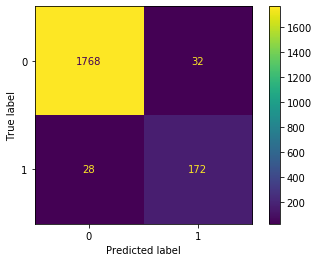

{'F1-score': 0.851, 'Accuracy': 0.97, 'Balanced Accuracy': 0.921, 'Recall': 0.86, 'Precision': 0.843, 'Specificity': 0.982, 'Cost': 0.127}


{'F1-score': 0.851,
 'Accuracy': 0.97,
 'Balanced Accuracy': 0.921,
 'Recall': 0.86,
 'Precision': 0.843,
 'Specificity': 0.982,
 'Cost': 0.127}

In [229]:
evaluate(y_test_sheart, model.predict(X_test_sheart))
evaluate(y_test_churn, model2.predict(X_test_churn))
evaluate(y_test_heart, model3.predict(X_test_heart))
evaluate(y_test_01, model4.predict(X_test_01))

Divergence between theory and practice => to explain. The cost will therefore be optimized similarly to other metrics. 

## Results

In [67]:
def grad_descent_sqbc(X_train, y_train, X_test, y_test): 

    model = JointQuantileModel()

    # Entraînement
    model.fit(X_train, y_train)

    # Prédiction directement avec le seuil optimal
    y_pred = model.predict(X_test)

    metrics = evaluate(y_test, y_pred, plot=False)
    metrics["Level_tau"] = model.tau
    print(metrics)

    return metrics

In [68]:
grad_sqbc_metrics_05 = grad_descent_sqbc(X_train_05, y_train_05, X_test_05, y_test_05)
grad_sqbc_metrics_01 = grad_descent_sqbc(X_train_01, y_train_01, X_test_01, y_test_01)
grad_sqbc_metrics_005 = grad_descent_sqbc(X_train_005, y_train_005, X_test_005, y_test_005)
grad_sqbc_metrics_002 = grad_descent_sqbc(X_train_002, y_train_002, X_test_002, y_test_002)
grad_sqbc_metrics_001 = grad_descent_sqbc(X_train_001, y_train_001, X_test_001, y_test_001)

grad_sqbc_metrics_sheart =  grad_descent_sqbc(X_train_sheart, y_train_sheart, X_test_sheart, y_test_sheart)
grad_sqbc_metrics_churn =  grad_descent_sqbc(X_train_churn, y_train_churn, X_test_churn, y_test_churn)
grad_sqbc_metrics_heart =  grad_descent_sqbc(X_train_heart, y_train_heart, X_test_heart, y_test_heart)
grad_sqbc_metrics_fraud =  grad_descent_sqbc(X_train_fraud, y_train_fraud, X_test_fraud, y_test_fraud)

resultats = {
    "grad_sqbc_metrics_05": grad_sqbc_metrics_05,
    "grad_sqbc_metrics_01": grad_sqbc_metrics_01,
    "grad_sqbc_metrics_005": grad_sqbc_metrics_005,
    "grad_sqbc_metrics_002": grad_sqbc_metrics_002,
    "grad_sqbc_metrics_001": grad_sqbc_metrics_001,
    "grad_sqbc_metrics_sheart": grad_sqbc_metrics_sheart,
    "grad_sqbc_metrics_churn": grad_sqbc_metrics_churn,
    "grad_sqbc_metrics_heart": grad_sqbc_metrics_heart,
    "grad_sqbc_metrics_fraud": grad_sqbc_metrics_fraud
}

with open("resultats_grad_sqbc.pkl", "wb") as f:
    pickle.dump(resultats, f)

{'F1-score': 0.997, 'Accuracy': 0.997, 'Balanced Accuracy': 0.997, 'Recall': 0.998, 'Precision': 0.996, 'Specificity': 0.996, 'Cost': 0.093, 'Level_tau': 0.4998891850415604}
{'F1-score': 0.323, 'Accuracy': 0.581, 'Balanced Accuracy': 0.767, 'Recall': 1.0, 'Precision': 0.193, 'Specificity': 0.534, 'Cost': 0.273, 'Level_tau': 0.539801355015887}
{'F1-score': 0.181, 'Accuracy': 0.546, 'Balanced Accuracy': 0.761, 'Recall': 1.0, 'Precision': 0.099, 'Specificity': 0.522, 'Cost': 0.348, 'Level_tau': 0.5449322194496272}
{'F1-score': 0.077, 'Accuracy': 0.518, 'Balanced Accuracy': 0.754, 'Recall': 1.0, 'Precision': 0.04, 'Specificity': 0.508, 'Cost': 0.425, 'Level_tau': 0.5479462639320426}
{'F1-score': 0.039, 'Accuracy': 0.509, 'Balanced Accuracy': 0.752, 'Recall': 1.0, 'Precision': 0.02, 'Specificity': 0.504, 'Cost': 0.46, 'Level_tau': 0.5489605929144039}
{'F1-score': 0.818, 'Accuracy': 0.803, 'Balanced Accuracy': 0.802, 'Recall': 0.818, 'Precision': 0.818, 'Specificity': 0.786, 'Cost': 0.26, 'L